In [6]:
import gymnasium as gym
import matplotlib.pyplot as plt

# Create CliffWalking-v0 environment with text rendering
env = gym.make("CliffWalking-v0", render_mode="ansi")

print("🧗 CliffWalking-v0 Environment")
print("Description: Navigate from start to goal avoiding the cliff in a grid.")
print("Number of states:", env.observation_space.n)  # 48 (4x12 grid)
print("Number of actions:", env.action_space.n)      # 4 (up, down, left, right)

print("\nReward structure:")
print("-1 per step, -100 if agent falls off cliff")

print("\nDeterministic environment: Yes")

# Reset environment
state, _ = env.reset()
print("\nInitial state:", state)
print(env.render())

# Hardcoded sequence of actions to move right 3 times
actions = [3, 3, 3]  # 3 is 'right' action

total_reward = 0
done = False

print("\nStarting manual/hardcoded action loop...")

for step, action in enumerate(actions):
    state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    print(f"\nStep {step+1}: Action = {action}")
    print(env.render())
    print(f"Reward received: {reward}")
    if terminated or truncated:
        print("Episode ended")
        break

print(f"\nTotal reward after {step+1} steps: {total_reward}")

# Close environment
env.close()

🧗 CliffWalking-v0 Environment
Description: Navigate from start to goal avoiding the cliff in a grid.
Number of states: 48
Number of actions: 4

Reward structure:
-1 per step, -100 if agent falls off cliff

Deterministic environment: Yes

Initial state: 36
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T



Starting manual/hardcoded action loop...

Step 1: Action = 3
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


Reward received: -1

Step 2: Action = 3
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


Reward received: -1

Step 3: Action = 3
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


Reward received: -1

Total reward 

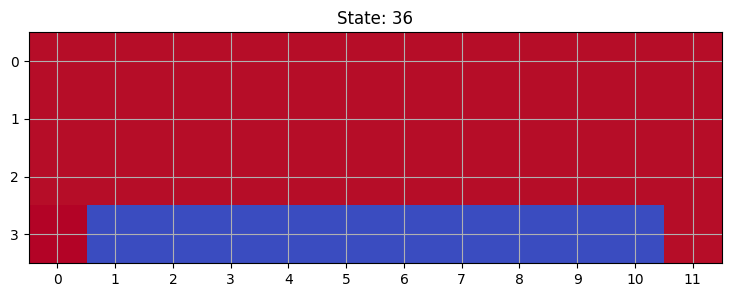

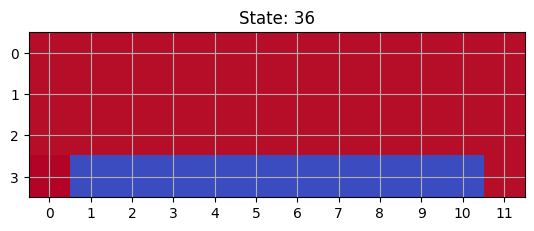

Step 1: Action=3, Reward=-1


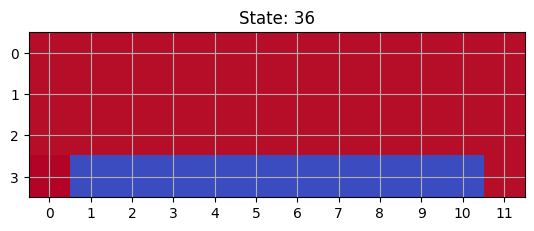

Step 2: Action=3, Reward=-1


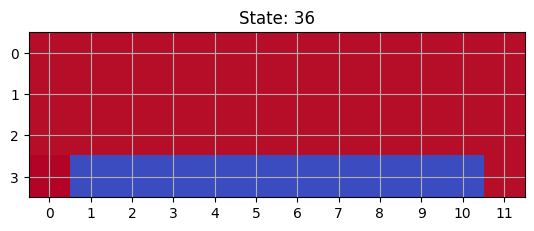

Step 3: Action=3, Reward=-1


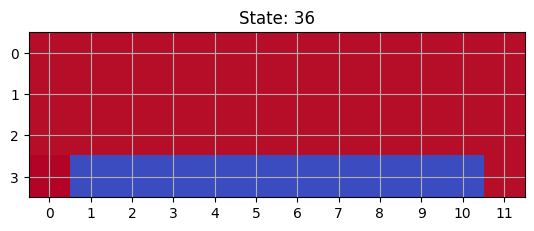

Step 4: Action=3, Reward=-1


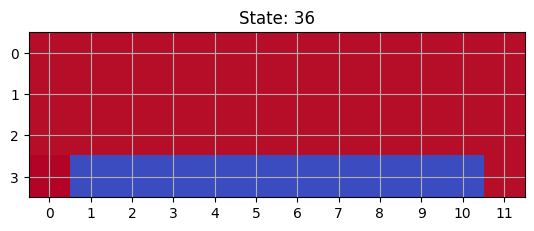

Step 5: Action=3, Reward=-1


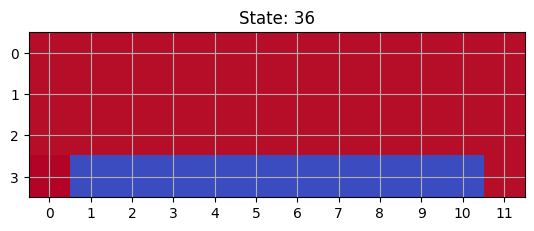

Step 6: Action=3, Reward=-1

Total reward: -6


In [7]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import time

# Create environment
env = gym.make("CliffWalking-v0")
state, _ = env.reset()

n_rows, n_cols = 4, 12

def plot_env(state):
    grid = np.zeros((n_rows, n_cols))
    
    # Mark cliff area
    grid[3, 1:-1] = -100
    
    # Mark agent
    row = state // n_cols
    col = state % n_cols
    grid[row, col] = 1

    # Create plot
    plt.imshow(grid, cmap="coolwarm", vmin=-100, vmax=1)
    plt.title(f"State: {state}")
    plt.xticks(range(n_cols))
    plt.yticks(range(n_rows))
    plt.grid(True)
    plt.pause(0.5)
    plt.clf()

plt.figure(figsize=(10, 3))
plot_env(state)

actions = [3, 3, 3, 3, 3, 3]  # Move right

total_reward = 0
for step, action in enumerate(actions):
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    plot_env(state)
    print(f"Step {step+1}: Action={action}, Reward={reward}")
    if terminated or truncated:
        print("Episode ended")
        break

plt.close()
env.close()
print(f"\nTotal reward: {total_reward}")
